# Analyse core genome recombinations with Gubbins

Recombination events are extracted with `annotate_recombinations.py`.

rsync -avz --progress becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_marie_project/ST131_corealignment /Users/mariebecker/documents/Uni/ETH/Masterarbeit
rsync -avz --progress becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_marie_project/2605_results /Users/mariebecker/documents/Uni/ETH/Masterarbeit

In [1]:
import pandas as pd

In [27]:
recombinations_block_df = pd.read_csv("../results/gubbins/recombination_block_long.csv")
recombinations_block_df.head(10)

,rec_id,start,end,length,branch,taxa,snp_count,block_id,block_length,overlap_length,pct_block_affected
0,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,WNLYKTZGKW,552,542,98.19
1,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,FZZJSRRGUR,1170,1170,100.00
2,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,CCBTELCMAW,1486,1486,100.00
3,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,DLZJDCRNUL,468,113,24.15
4,rec_1,1104872,1105085,214,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],5,IZBZUHLGQE,9814,213,2.17
5,rec_2,1551484,1551521,38,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,TJTLWATQFF,1832,37,2.02
6,rec_3,44510,44576,67,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,TYNDBFDKGO,3979,66,1.66
7,rec_4,2902652,2961122,58471,Node_5->NZ_CP015069.1,['NZ_CP015069.1'],907,QHGKDXJCDB,14600,12768,87.45
8,rec_4,2902652,2961122,58471,Node_5->NZ_CP015069.1,['NZ_CP015069.1'],907,ISADOQMCVR,5922,5922,100.00
9,rec_4,2902652,2961122,58471,Node_5->NZ_CP015069.1,['NZ_CP015069.1'],907,JKXDSPORHF,1914,1914,100.00


In [26]:
recombinations_junction_df = pd.read_csv("../results/gubbins/recombination_junction_long.csv")
recombinations_junction_df.head(10)

,rec_id,start,end,length,branch,taxa,snp_count,junction_name,overlap_length,combined_core_length,pct_core_length_covered,n_blocks_affected,n_blocks_junction,pct_blocks_affected
0,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,EVCCMUBHOL_r__WNLYKTZGKW_f,542,11948,4.54,1,2,50.00
1,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,FZZJSRRGUR_r__WNLYKTZGKW_r,1712,1722,99.42,2,2,100.00
2,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,CCBTELCMAW_r__FZZJSRRGUR_r,2656,2656,100.00,2,2,100.00
3,rec_0,165287,168598,3312,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],239,CCBTELCMAW_f__XDNOEMXHOO_f,1599,3432,46.59,2,3,66.67
4,rec_1,1104872,1105085,214,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],5,HMHDANERBU_r__IZBZUHLGQE_r,213,11556,1.84,1,2,50.00
5,rec_1,1104872,1105085,214,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],5,IZBZUHLGQE_r__XIDWLBCHGM_r,213,12426,1.71,1,2,50.00
6,rec_2,1551484,1551521,38,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,BWLQZIEPEC_f__TJTLWATQFF_f,37,4762,0.78,1,2,50.00
7,rec_2,1551484,1551521,38,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,RPKQPTEKVL_f__TJTLWATQFF_r,37,14512,0.25,1,2,50.00
8,rec_3,44510,44576,67,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,TYNDBFDKGO_r__YELGYGVCLQ_r,66,14501,0.46,1,2,50.00
9,rec_3,44510,44576,67,Node_2->NZ_CP128916.1,['NZ_CP128916.1'],3,QWMTKCOYQH_f__TYNDBFDKGO_r,66,4646,1.42,1,2,50.00


In [33]:
min_pct, min_bp = 20, 500

junction_rec_counts = (
    recombinations_junction_df[(recombinations_junction_df["pct_core_length_covered"] >= min_pct) &(recombinations_junction_df["overlap_length"] >= min_bp)]
    .groupby("junction_name")["rec_id"].nunique().reset_index(name="n_recombinations")
)

jdf_all = pd.read_csv("../results/junction_summary_df.csv")
jdf_all = (jdf_all.merge(junction_rec_counts, on="junction_name", how="left"))

jdf_all["n_recombinations"] = jdf_all["n_recombinations"].fillna(0).astype(int)

junction_rec_counts

,junction_name,n_recombinations
0,AFFODHUCNW_f__KDNDVPYXTO_f,2
1,AFFODHUCNW_r__VRDEBAMMSO_r,1
2,AHYRAMUUTM_f__OWNWVIRSZP_f,1
3,AHYRAMUUTM_r__QQXNMUYDNS_r,2
4,AOMYVKXUJH_f__DVVYKKYAWE_f,2
...,...,...
170,VZTFXIZVXB_f__YOCIMVGHSL_f,1
171,WOABSWWVRB_r__YNFGSNJILT_r,2
172,WZDCCWPRYS_r__XNUJCMVIGS_r,1
173,XXVMWZCEKI_r__YUOECYBHUS_r,13


In [35]:
jdf_all[['n_clusters', 'n_recombinations']]

,n_clusters,n_recombinations
0,2,0
1,1,0
2,3,4
3,1,0
4,2,1
...,...,...
513,1,2
514,1,0
515,2,0
516,1,0


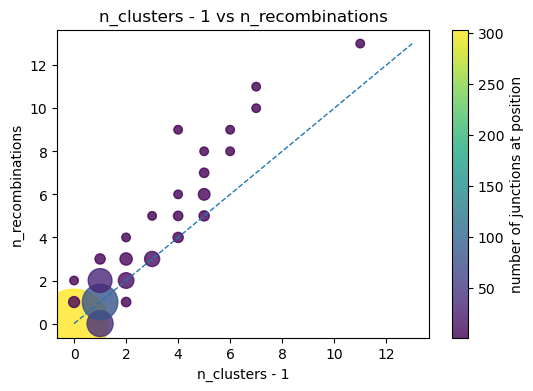

In [52]:
import matplotlib.pyplot as plt

# use shifted x values
plot_df = jdf_all.copy()
plot_df["x"] = plot_df["n_clusters"] - 1
plot_df["y"] = plot_df["n_recombinations"]

# count how many junctions fall on the same (x, y) position
density_df = (
    plot_df.groupby(["x", "y"])
    .size()
    .reset_index(name="n_junctions")
)

plt.figure(figsize=(6, 4))

sc = plt.scatter(
    density_df["x"],
    density_df["y"],
    c=density_df["n_junctions"],
    s=30 + density_df["n_junctions"] * 8,   # optional: slightly larger for denser points
    alpha=0.8,
    cmap="viridis"
)

# diagonal line through 0
max_val = max(density_df["x"].max(), density_df["y"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("n_clusters - 1")
plt.ylabel("n_recombinations")
plt.title("n_clusters - 1 vs n_recombinations")
plt.grid(True, alpha=0.01)
plt.colorbar(sc, label="number of junctions at position")

plt.show()

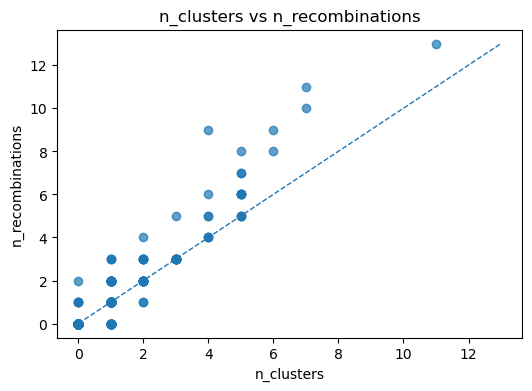

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(
    jdf_all["n_clusters"] - 1,  # subtract 1 to get number of additional clusters coming from recombination events
    jdf_all["n_recombinations"],
    alpha=0.7
)

# diagonal line through 0 with slope 1
max_val = max(jdf_all["n_clusters"].max(), jdf_all["n_recombinations"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("n_clusters")
plt.ylabel("n_recombinations")
plt.title("n_clusters vs n_recombinations")
plt.grid(True, alpha=0.01)
plt.show()

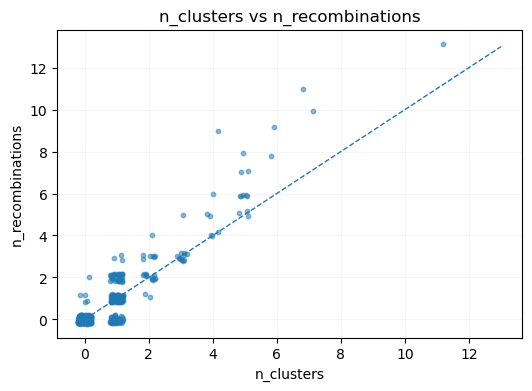

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# small random jitter
np.random.seed(42)
jitter = 0.2

x = jdf_all["n_clusters"] - 1 + np.random.uniform(-jitter, jitter, size=len(jdf_all))
y = jdf_all["n_recombinations"] + np.random.uniform(-jitter, jitter, size=len(jdf_all))

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.5, s=10)
max_val = max(jdf_all["n_clusters"].max(), jdf_all["n_recombinations"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)
plt.xlabel("n_clusters")
plt.ylabel("n_recombinations")
plt.title("n_clusters vs n_recombinations")
plt.grid(True, alpha=0.1)
plt.show()

In [ ]:
# try out plot_density_scatter

## Rerun with new junstions

I need matching block ids to junctions, since I have now only two flanking core blocks left, I can use that to calculate overlap with a junction.

In [3]:
recombinations_block_df = pd.read_csv("../results/gubbins_new/recombination_block_long.csv")
recombinations_block_df

,rec_id,start,end,length,branch,taxa,snp_count,block_id,block_length,overlap_length,pct_block_affected
0,rec_0,1483883,1486988,3106,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],235,8997014266051117024,552,542,98.19
1,rec_0,1483883,1486988,3106,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],235,1283811295721661634,1193,1170,98.07
2,rec_0,1483883,1486988,3106,Node_1->NZ_CP015074.2,['NZ_CP015074.2'],235,7434944484282563815,1470,1393,94.76
3,rec_1,2885190,2889696,4507,Node_174->NZ_AP026788.1,['NZ_AP026788.1'],4,5988578141804533070,19465,4506,23.15
4,rec_2,692519,698817,6299,Node_176->NZ_CP076693.1,['NZ_CP076693.1'],191,14995126079118934230,10084,6298,62.46
...,...,...,...,...,...,...,...,...,...,...,...
495,rec_206,3321881,3322662,782,Node_221->Node_220,['NZ_CP134384.1 NZ_CP124467.1 NZ_CP019008.1 ...,6,2533819544623770507,24346,781,3.21
496,rec_207,1180947,1181073,127,Node_221->Node_220,['NZ_CP134384.1 NZ_CP124467.1 NZ_CP019008.1 ...,4,4754345761672885668,7195,126,1.75
497,rec_208,1344017,1344032,16,Node_221->Node_220,['NZ_CP134384.1 NZ_CP124467.1 NZ_CP019008.1 ...,4,9362578873613198877,7394,15,0.20
498,rec_209,2977521,2977527,7,Node_221->Node_220,['NZ_CP134384.1 NZ_CP124467.1 NZ_CP019008.1 ...,3,1200297927848536995,25397,6,0.02
